In [1]:
import warnings

warnings.filterwarnings("ignore")

#### Our Imports ??

In [2]:
from typing import Annotated, Literal, Sequence, TypedDict
from pydantic import BaseModel, Field

from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.tools.retriever import create_retriever_tool

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

#### Prepare The AI and Embedding Model ??

In [4]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

llm = ChatGroq(model_name="Gemma2-9b-It")

In [5]:
llm.invoke("Explain me Chain Of Thought Technique in LLMs.")

AIMessage(content='## Chain-of-Thought Prompting: Thinking Step-by-Step\n\nChain-of-thought prompting is a technique used to improve the reasoning abilities of large language models (LLMs). \n\n**The basic idea:** Instead of directly asking an LLM for the answer to a question, you guide it through a series of intermediate steps, encouraging it to think step-by-step like a human. This "chain of thought" helps the model break down complex problems and arrive at more accurate and logical solutions.\n\n**How it works:**\n\n1. **Present the problem:** You start by asking the LLM the original question, just as you would normally.\n2. **Guide the thought process:** You then provide additional instructions, prompting the LLM to think through the problem systematically. This can involve:\n    * **Asking clarifying questions:** "What information do we need to solve this?"\n    * **Suggesting relevant concepts:** "This problem seems to involve..."\n    * **Outlining a step-by-step approach:** "He

#### Loading Docs, Text Splitter, Creating Chunks, Chroma Vector DB, and Retriver ??

In [6]:
url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

WebBaseLoader(url).load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [7]:
docs = WebBaseLoader(url).load()

In [8]:
docs[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [9]:
docs[0].metadata['description']

'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model 

In [10]:
doc_list = [item for sublist in docs for item in sublist]

doc_list

[('id', None),
 ('metadata',
  {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
   'title': "LLM Powered Autonomous Agents | Lil'Log",
   'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the qua

In [11]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100,
    chunk_overlap=5
)

In [12]:
doc_splits = text_splitter.split_documents(docs)

doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [13]:
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="agentic-rag",
    embedding=embeddings
)

In [14]:
retriever = vectorstore.as_retriever()

In [15]:
retriever

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001BB5A176D90>, search_kwargs={})

In [16]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response."
)

In [17]:
retriever_tool

Tool(name='retrieve_blog_posts', description="Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.", args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001BB40CA2E80>, retriever=VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001BB5A176D90>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<funct

In [18]:
tools = [retriever_tool]

In [19]:
retrieve = ToolNode(tools)

In [20]:
retrieve

tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'retrieve_blog_posts': Tool(name='retrieve_blog_posts', description="Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.", args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001BB40CA2E80>, retriever=VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001BB5A176D90>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_c

#### Setup Function For Creating Graph ?? 

In [21]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [22]:
def AI_Assistant (state: AgentState):
    print("====== CALL AGENT ======")
    
    messages = state['messages']
    llm_with_tools = llm.bind_tools(tools)
    response = llm_with_tools.invoke(messages)
    
    return { "messages": [response] }

In [23]:
class grade(BaseModel):
    binary_score: str = Field(description="Relevance score 'yes' or 'no'")

In [24]:
def grade_documents(state: AgentState) -> Literal["Output_Generator", "Query_Rewriter"]:
    llm_with_structure_op = llm.with_structured_output(grade)
    
    prompt = PromptTemplate(
        template="""
            You are a grader deciding if a document is relevant to a user’s question.
            Here is the document: {context}
            Here is the user’s question: {question}
            If the document talks about or contains information related to the user’s question, mark it as relevant. 
            Give a 'yes' or 'no' answer to show if the document is relevant to the question.
        """,
        input_variables=["context", "question"]
    )
    
    chain = prompt | llm_with_structure_op
    
    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content
    scored_result = chain.invoke({"question": question, "context": docs})
    score = scored_result.binary_score

    if score == "yes":
        print("==== DECISION: DOCS RELEVANT ====")
        return "generator" #this should be a node name
    else:
        print("==== DECISION: DOCS NOT RELEVANT ====")
        return "rewriter" #this should be a node name

In [34]:
hub.pull("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [35]:
def Generate (state: AgentState):
    print("====== GENERATOR ======")
    
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content
    prompt = hub.pull("rlm/rag-prompt")
    rag_chain = prompt | llm
    response = rag_chain.invoke({"context": docs, "question": question})
    
    print(f"This Is My Response -> {response}")
    
    return {"messages": [response]}

In [27]:
def Rewrite (state: AgentState):
    print("====== TRANSFORM QUERY ======")
    messages = state["messages"]
    question = messages[0].content
    
    message = [
        HumanMessage(content=f"""
            Look at the input and try to reason about the underlying semantic intent or meaning. 
            Here is the initial question: {question} 
            Formulate an improved question: 
        """)
    ]
    
    response = llm.invoke(message)
    
    return {"messages": [response]}

### Let's Create the Graph ??

In [36]:
workflow = StateGraph(AgentState)

In [37]:
workflow.add_node("MY_AI_Assistant", AI_Assistant)
workflow.add_node("Vector_Retriever", retrieve)
workflow.add_node("Output_Generator", Generate)
workflow.add_node("Query_Rewriter", Rewrite)

In [38]:
workflow.add_edge(START, "MY_AI_Assistant")

workflow.add_conditional_edges(
    "MY_AI_Assistant",
    tools_condition,
    {
        "tools": "Vector_Retriever",
        END: END
    }
)

workflow.add_conditional_edges(
    "Vector_Retriever",
    grade_documents,
    {
        "generator": "Output_Generator",
        "rewriter": "Query_Rewriter"
    }
)

workflow.add_edge("Query_Rewriter", "MY_AI_Assistant")

workflow.add_edge("Output_Generator", END)

In [39]:
app = workflow.compile()

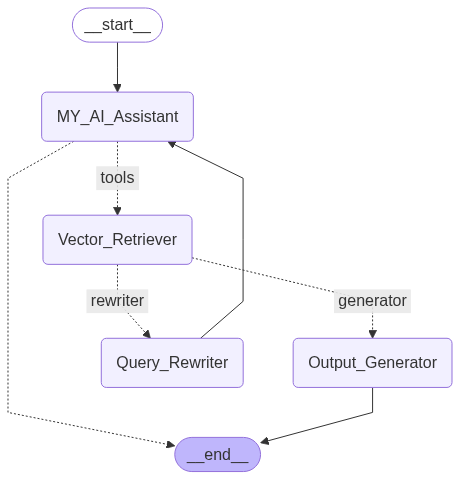

In [32]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(f"Error -> {e}")

In [40]:
app.invoke({"messages":["What is a Autonomous Agent?"]})

====== CALL AGENT ======
==== DECISION: DOCS RELEVANT ====
====== GENERATOR ======
This Is My Response -> content='An Autonomous Agent is a system that can act independently to accomplish a goal.  \n\nIt plans its own actions, reacts to its environment, and can even use external tools to gather information.  Autonomous agents are often powered by large language models (LLMs). \n' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 371, 'total_tokens': 427, 'completion_time': 0.101818182, 'prompt_time': 0.007750292, 'queue_time': 0.189109517, 'total_time': 0.109568474}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None} id='run--a2d9b98a-4736-4c08-82ff-4e4bb88601db-0' usage_metadata={'input_tokens': 371, 'output_tokens': 56, 'total_tokens': 427}


{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='3e48d788-97d7-43b0-8388-b5c7b2e41e31'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '5w3taykp2', 'function': {'arguments': '{"query":"What is an autonomous agent?"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 1038, 'total_tokens': 1126, 'completion_time': 0.16, 'prompt_time': 0.021059933, 'queue_time': 0.190924004, 'total_time': 0.181059933}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b8e2d862-a722-4b61-9c8d-b1c139d36f2c-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'What is an autonomous agent?'}, 'id': '5w3taykp2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1038, 'output_tokens': 88, 'total_tokens': 1126}),
  ToolMessag

In [41]:
app.invoke({"messages":["what is a prompt engineering explain me in terms of agents and langchain?"]})

====== CALL AGENT ======
==== DECISION: DOCS RELEVANT ====
====== GENERATOR ======
This Is My Response -> content="Prompt engineering in the context of agents and LangChain involves carefully crafting instructions (prompts) to guide the LLM-powered agent's behavior. \n\nThese prompts define the agent's goals, actions, and how it interacts with its environment, represented as a tree structure in LangChain. Effective prompt engineering is crucial for enabling agents to perform complex tasks and make informed decisions. \n" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 378, 'total_tokens': 459, 'completion_time': 0.147272727, 'prompt_time': 0.010346812, 'queue_time': 0.189333446, 'total_time': 0.157619539}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None} id='run--7fe8e97e-9c4b-409e-a0b5-6796be2fc1f1-0' usage_metadata={'input_tokens': 378, 'output

{'messages': [HumanMessage(content='what is a prompt engineering explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='ceb95fd8-4cad-4d34-b722-01b824473ef0'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dmxnaj426', 'function': {'arguments': '{"query":"explain prompt engineering in terms of agents and langchain"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 1047, 'total_tokens': 1138, 'completion_time': 0.165454545, 'prompt_time': 0.024584333, 'queue_time': 0.190606864, 'total_time': 0.190038878}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--fe857239-f3a8-4dc1-98a0-53fd38a04c26-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'explain prompt engineering in terms of agents and langchain'}, 'id': 'dmxnaj426', 'ty